# Interactive Stack Viewing & Dual X-Axis Plotting

This notebook demonstrates two visualization utilities from `escape.plot_utilities`:

1. **`StackViewer`** — an interactive slider viewer for 3-D image stacks, with lazy
   dask loading. It accepts several different kinds of input, shown below.
2. **Dual / secondary x-axis plotting** — for labelling a plot's x-axis with a second
   quantity, most commonly a scan's step number.

All plotting here uses the interactive `ipympl` (`%matplotlib widget`) backend, so
every figure below — including each `StackViewer` — is a live, pannable/zoomable
widget when you run this notebook in Jupyter (requires `pip install ipympl`). Turning
point labels in Part 2 use `adjustText` (`pip install adjustText`) to avoid
overlapping text.

> **Why don't the sliders/ROI move in this pre-rendered copy?** Dragging the slider or
> the ROI box fires a Python callback (compute a new dask mean, recompute an ROI
> average, …) — that only happens with a live kernel behind the notebook. A static
> export (like this file rendered for the docs site, or this file opened without
> connecting a kernel) can only show the widget's *last* visual state — there's no
> Python running to answer new drag events. That's a hard requirement, not a missing
> feature: only options are "run it yourself" or serve the notebook itself off a live
> kernel (Voilà / Binder / JupyterLite) — a separate infrastructure decision if you
> want that for the docs site itself. Each demo below shows a single `display(viewer)`
> call: in a live kernel that's the real interactive widget; a static export shows
> whatever snapshot got captured in the widget's state, which modern renderers
> (JupyterLab, VS Code, nbsphinx) reconstruct as a static image.

In [1]:
from _devpath import prepend_local_checkout_to_path
prepend_local_checkout_to_path()
%matplotlib widget

In [2]:
import time
import numpy as np
import dask.array as da
import matplotlib.pyplot as plt
from IPython.display import display

import escape
from escape.storage.example_data import make_scan, make_image_scan
from escape.plot_utilities import (
    StackViewer,
    dual_x_axis_plot,
    add_crossing_secondary_axis,
    add_step_secondary_axis,
)

print(f"escape version: {escape.__version__}")

escape version: 0.2.1


## Part 1 — `StackViewer`: browsing a 3-D image stack

`StackViewer(array, ...)` adapts its behaviour to what you pass in:

| Input | Mode | Behaviour |
|---|---|---|
| `escape.Array` **with** a multi-step scan | *step mode* | one image per scan step: the mean over that step's events |
| `escape.Array` **without** a scan (or a single-step scan) | *frame mode* | one image per event/frame, no averaging |
| raw 3-D `numpy.ndarray` | *frame mode* | one image per frame |
| raw 3-D `dask.array.Array` | *frame mode*, lazy | frames are only computed when visited |

For **dask-backed step data**, moving the slider first shows a cheap preview (mean of
`preview_frames` events) and, if the slider stays put for `refine_delay` seconds,
replaces it with the full-step mean computed in a background thread — so scrubbing
through a large scan stays responsive. Nothing is computed until a slider position is
actually visited, for either step or frame mode.

We build a small synthetic Bragg-peak scan with `make_image_scan` (the peak shifts by
1.5 px per step) to exercise every mode below. Each demo below calls `display(viewer)`
once to show the live interactive widget (image, slider and status grouped together;
with `rois=True`, the ROI tabs and trend plot flow alongside it, flex-wrapping to the
available width).

In [3]:
imgs = make_image_scan(
    n_steps=6, n_events_per_step=40, image_shape=(48, 48), seed=0,
)
print(imgs)
print(imgs.scan.par_steps)

<escape.storage.storage.Array object at 0x77d6c8c00e30> detector_image; shape (240, 48, 48)
Scan over 6 steps
Parameters motor_mm
   motor_mm  step_length
0       0.0           40
1       1.0           40
2       2.0           40
3       3.0           40
4       4.0           40
5       5.0           40


### 1a — `escape.Array` with a scan, numpy-backed (step mode)

The most common case: one image per scan step, averaged over the step's events.
Since the data is plain numpy, each step's mean is computed synchronously — no
preview/refine cycle is needed.

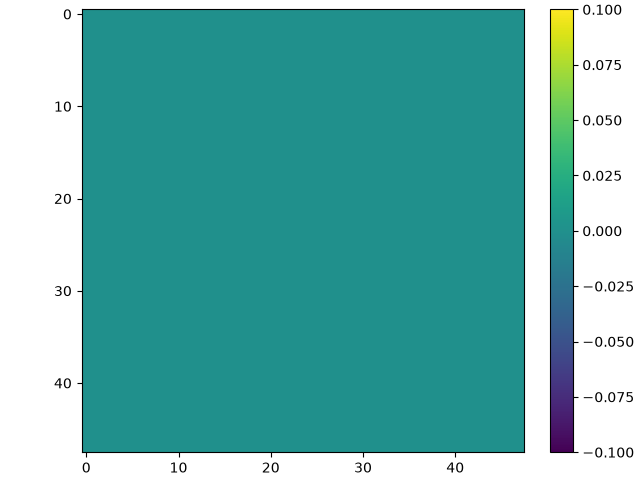

StackViewer(children=(VBox(children=(Output(), HBox(children=(IntSlider(value=0, description='index', max=5), …

In [4]:
viewer_step = StackViewer(imgs, figname="step-numpy")
time.sleep(0.3)  # let the initial frame render
display(viewer_step)   # live: drag the slider

### 1b — `escape.Array` with a scan, **dask-backed** (step mode, lazy)

Wrapping the same data in a `dask.array` triggers the preview → refine path: the
status label first shows `(preview…)` using only `preview_frames` events, then
upgrades to the full per-step mean once `refine_delay` seconds have passed without
the slider moving.

is_dask_array: True


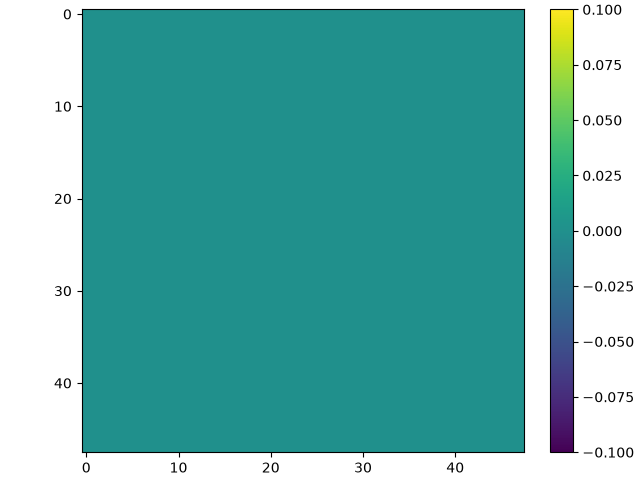

status just after the preview loads: {'motor_mm': np.float64(0.0), 'step_length': np.float64(40.0)} (preview…)


status after refine_delay:           {'motor_mm': np.float64(0.0), 'step_length': np.float64(40.0)}


StackViewer(children=(VBox(children=(Output(), HBox(children=(IntSlider(value=0, description='index', max=5), …

In [5]:
dask_data = da.from_array(imgs.data, chunks=(10, 48, 48))
imgs_dask = escape.Array(
    data=dask_data,
    index=imgs.index,
    step_lengths=imgs.scan.step_lengths,
    parameter=imgs.scan.parameter,
    name="detector_image_dask",
)
print("is_dask_array:", imgs_dask.is_dask_array())

viewer_dask = StackViewer(imgs_dask, figname="step-dask", preview_frames=8, refine_delay=0.4)
time.sleep(0.1)
print("status just after the preview loads:", viewer_dask.status.value)  # "... (preview…)"
time.sleep(0.8)
print("status after refine_delay:          ", viewer_dask.status.value)  # full mean
display(viewer_dask)

### 1c — scan-less `escape.Array` (frame mode)

An `escape.Array` with a single implicit step (no `parameter=` scan metadata) has
`len(array.scan) == 1`, so `StackViewer` falls back to *frame mode*: one image per
event, no averaging.

len(scan): 1


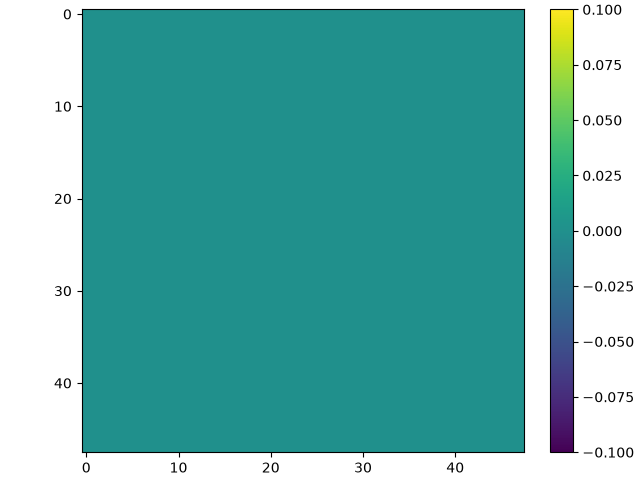

StackViewer(children=(VBox(children=(Output(), HBox(children=(IntSlider(value=0, description='index', max=29),…

In [6]:
imgs_noscan = make_image_scan(n_steps=1, n_events_per_step=30, image_shape=(48, 48), seed=1)
print("len(scan):", len(imgs_noscan.scan))

viewer_frame = StackViewer(imgs_noscan, figname="frame-escape-array")
time.sleep(0.3)
display(viewer_frame)

### 1d — raw 3-D numpy array (frame mode)

`StackViewer` also accepts a bare array, with no `escape.Array` wrapper at all.

<class 'numpy.ndarray'> (240, 48, 48)


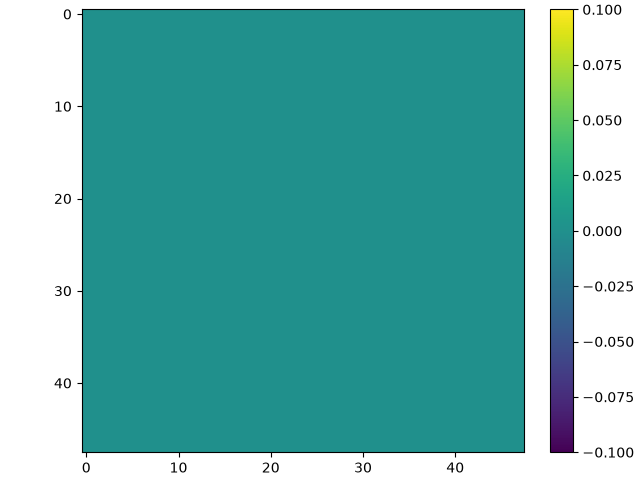

StackViewer(children=(VBox(children=(Output(), HBox(children=(IntSlider(value=0, description='index', max=239)…

In [7]:
raw_numpy_stack = imgs.data  # plain (n_events, ny, nx) ndarray
print(type(raw_numpy_stack), raw_numpy_stack.shape)

viewer_numpy = StackViewer(raw_numpy_stack, figname="frame-numpy")
time.sleep(0.3)
display(viewer_numpy)

### 1e — raw 3-D dask array (frame mode, lazy)

A bare `dask.array` also works, and stays lazy: only frames you actually visit with
the slider are computed and cached.

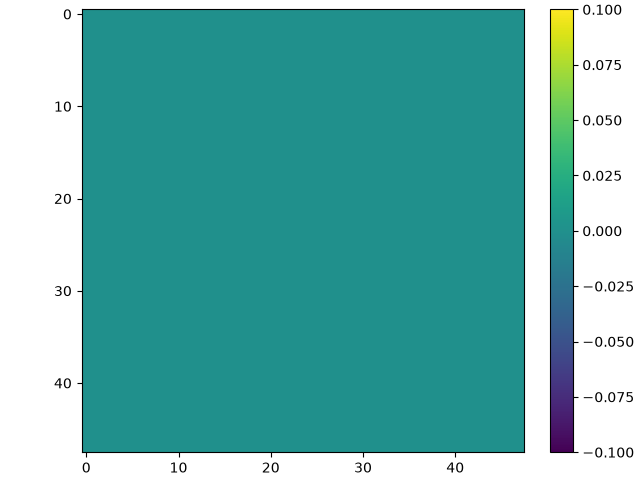

cached frames after creation: [0]


cached frames after visiting 2 and 5: [0, 2, 5]


StackViewer(children=(VBox(children=(Output(), HBox(children=(IntSlider(value=5, description='index', max=239)…

In [8]:
raw_dask_stack = da.from_array(raw_numpy_stack, chunks=(20, 48, 48))

viewer_rawdask = StackViewer(raw_dask_stack, figname="frame-dask")
time.sleep(0.3)
print("cached frames after creation:", sorted(viewer_rawdask._image_cache))

for i in (2, 5):
    viewer_rawdask.slider.value = i
    time.sleep(0.2)
print("cached frames after visiting 2 and 5:", sorted(viewer_rawdask._image_cache))
display(viewer_rawdask)

### 1f — with ROI selection (`rois=True`), now updating live while you drag

Setting `rois=True` gives `viewer.roi_panel`, a `RoiPanel`: rectangles are drawn
directly on the same main image (no second copy of it), each with its own colour,
tab (a cropped preview + editable name) and entry in an adjacent trend plot — all
flowing alongside the main image in the same flex-wrapping widget. Click **Add ROI**
to add one interactively, or call `viewer.roi_panel.add_region(extents=...)` as below.

Each region's mean updates continuously **while you drag** its rectangle, not just
after you release the mouse — matplotlib already updates the rectangle's `.extents`
live during a drag; `RoiRegion` just also redraws on every such update instead of
waiting for the release event. That's inherently a "run it yourself" thing — there's
no drag gesture to bake into a static export — so to still show *something* concrete,
we drive the same code path the live drag uses (`RoiRegion._on_motion`) through a few
successive rectangle sizes, the way a real drag would call it repeatedly:

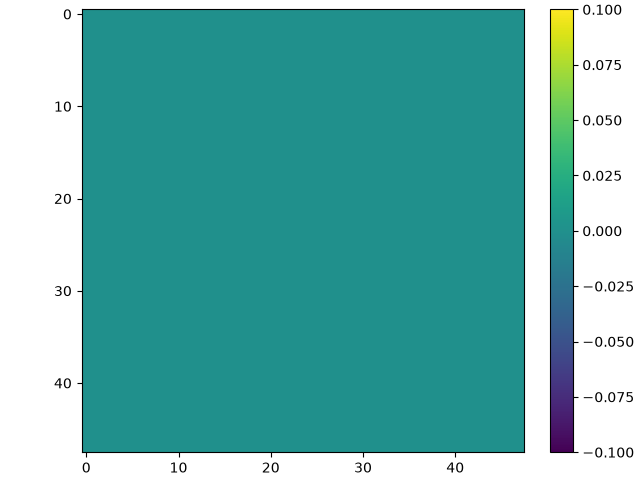

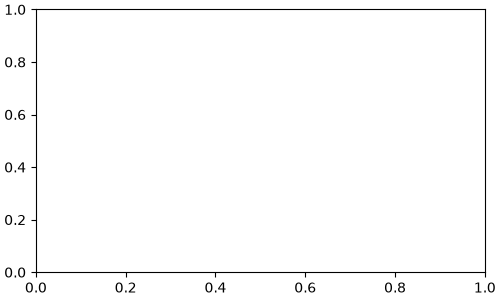

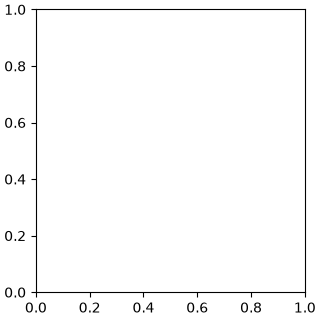

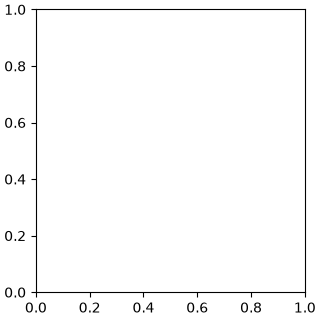

StackViewer(children=(VBox(children=(Output(), HBox(children=(IntSlider(value=5, description='index', max=5), …

In [9]:
viewer_roi = StackViewer(imgs, figname="with-rois", rois=True)
time.sleep(0.3)

# Equivalent of clicking "Add ROI" and dragging a box over the peak region:
roi_peak = viewer_roi.roi_panel.add_region(extents=(15, 25, 15, 25), name="peak")
# A second region, to show off per-region colour coding (rectangle, tab, trend line):
roi_bg = viewer_roi.roi_panel.add_region(extents=(2, 12, 2, 12), name="background")

# Visit every step so each region's mean gets recorded (a live UI would do this as
# you scrub the slider yourself):
for i in range(len(imgs.scan)):
    viewer_roi.slider.value = i
    time.sleep(0.05)

display(viewer_roi)

dragged to (15, 30, 15, 30) -> peak means: {0: 2.076557159423828, 1: 1.4344426393508911, 2: 0.9907985925674438, 3: 0.7411602139472961, 4: 0.6063817143440247, 5: 0.5460324883460999}
dragged to (15, 35, 15, 38) -> peak means: {0: 7.83408260345459, 1: 7.233288764953613, 2: 6.436667442321777, 3: 5.303485870361328, 4: 4.146965026855469, 5: 3.003298759460449}
dragged to (15, 40, 15, 42) -> peak means: {0: 7.638764381408691, 1: 7.538509845733643, 2: 7.397801876068115, 3: 6.961299419403076, 4: 6.400625228881836, 5: 5.558814525604248}


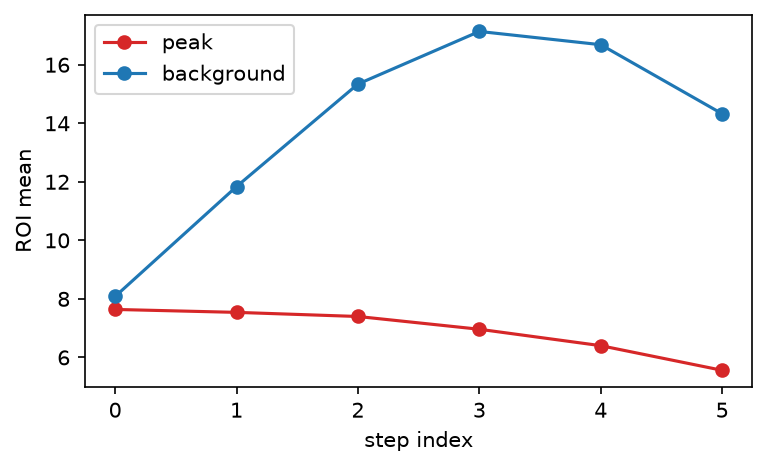

In [10]:
# Simulate the rest of a mouse drag on the "peak" region: matplotlib keeps
# `_eventpress` truthy while a button is held down, and updates `.extents` live as
# the mouse moves; RoiRegion._on_motion reacts to each such update exactly like it
# would during a real drag (the event argument itself isn't used, so None is fine).
roi_peak.selector.set_active(True)
roi_peak.selector._eventpress = True
for extents in [(15, 30, 15, 30), (15, 35, 15, 38), (15, 40, 15, 42)]:
    roi_peak.extents = extents
    roi_peak._on_motion(None)
    print(f"dragged to {extents} -> {roi_peak.name} means: {viewer_roi._roi_means[roi_peak.name]}")
roi_peak.selector._eventpress = None

# viewer_roi (displayed above) updates live in place in a running kernel; shown again
# here only so a static export also shows the trend *after* the simulated drag.
viewer_roi.trend_fig

### 1g — physical coordinates and colormap options

`StackViewer` also accepts `xdata`/`ydata` (physical, possibly non-uniform coordinates
for the image's columns/rows -- switches internally from `imshow` to `pcolormesh`,
since `imshow` only supports a uniform pixel grid) and `norm` (`"log"`, `"symlog"`,
`"diverging"`, `"two_slope"`, `"power"`, or your own `matplotlib.colors.Normalize`
instance) for scientific color scaling -- the same options `escape.utilities.plot2D`
offers, plus two more. ROI previews automatically get a matching colormap *and* norm
(not just matching `vmin`/`vmax`), and `autoscale="percentile"` makes the per-frame
auto-rescale robust to hot pixels/cosmic rays instead of the default raw min/max.

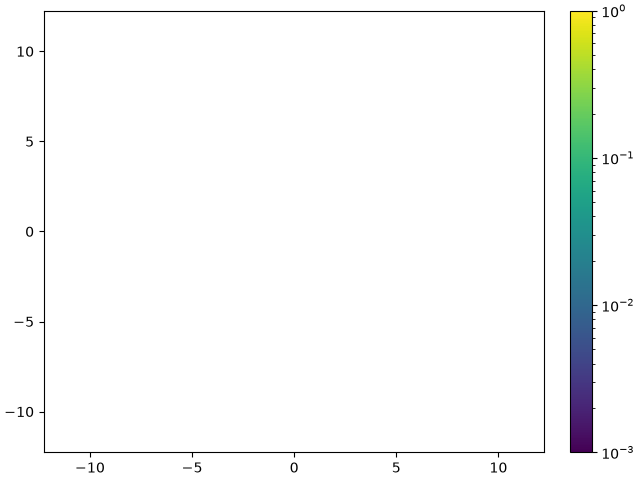

StackViewer(children=(VBox(children=(Output(), HBox(children=(IntSlider(value=0, description='index', max=5), …

In [12]:
# Real detector coordinates (mm) instead of pixel indices, log-scaled counts, and
# percentile-based autoscaling so a single hot pixel can't blow out the whole range.
detector_x = np.linspace(-12, 12, 48)  # mm
detector_y = np.linspace(-12, 12, 48)  # mm

viewer_log = StackViewer(
    imgs, figname="log-physical-coords",
    xdata=detector_x, ydata=detector_y,
    norm="log", autoscale="percentile", autoscale_percentile=(1, 99),
)
time.sleep(0.3)
display(viewer_log)

Diverging data — e.g. a pump-probe *difference* image — benefits from
`norm="two_slope"`: it centers on `vcenter` (0 by default) but, unlike `"diverging"`
(symmetric `CenteredNorm`), allows independent positive/negative ranges either side of
it, which is usually closer to what real difference data looks like than forcing exact
symmetry.

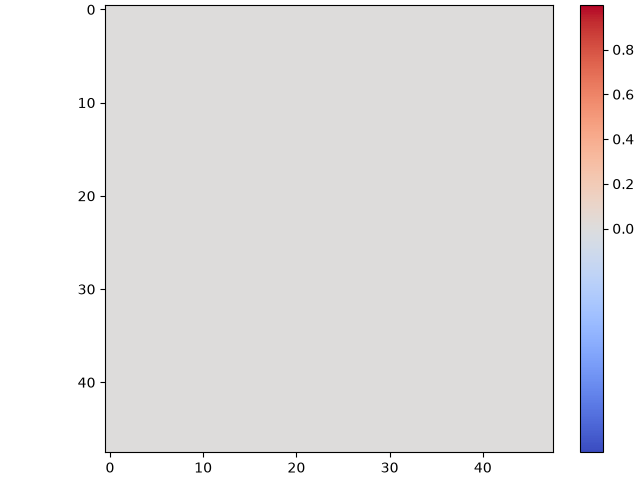

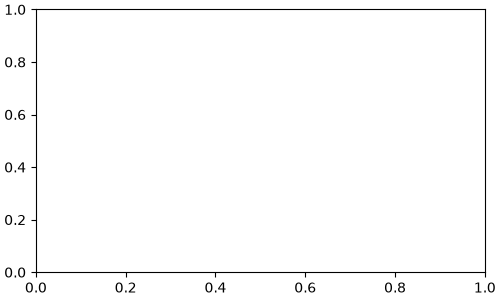

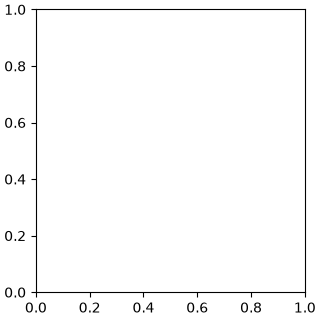

StackViewer(children=(VBox(children=(Output(), HBox(children=(IntSlider(value=5, description='index', max=5), …

In [13]:
diff_images = imgs.data.astype(float) - imgs.data.mean(axis=0)  # this step vs. the scan-average

diff_arr = escape.Array(
    data=diff_images, index=imgs.index, step_lengths=imgs.scan.step_lengths,
    parameter=imgs.scan.parameter, name="difference_image",
)

viewer_diverging = StackViewer(
    diff_arr, figname="diverging-demo", rois=True,
    norm="two_slope", norm_kwargs={"vcenter": 0.0}, cmap="coolwarm",
)
time.sleep(0.3)
diff_roi = viewer_diverging.roi_panel.add_region(extents=(15, 35, 15, 35), name="peak")
for i in range(len(diff_arr.scan)):
    viewer_diverging.slider.value = i
display(viewer_diverging)

### Cleanup

Call `close_viewer()` when you're done with a `StackViewer` to cancel any pending
background refine timers/threads and close its figures.

In [14]:
for v in [viewer_step, viewer_dask, viewer_frame, viewer_numpy, viewer_rawdask, viewer_roi,
          viewer_log, viewer_diverging]:
    v.close_viewer()

## Part 2 — Dual / secondary x-axis plotting

Sometimes you want to plot `y` against a parameter `x1`, but *also* label the same
points with a second quantity `x2`.

Matplotlib's built-in `Axes.secondary_xaxis(functions=(fwd, inv))` assumes an
invertible, monotonic relationship between the two axes; it breaks down as soon as
`x2` reverses or repeats. This module gives you two tools for that:

* **`add_crossing_secondary_axis`** / **`dual_x_axis_plot`** — fully general: `x2` can
  be *anything*, monotonic or not, related to `x1` or not. It works by walking the
  paired `(x1, x2)` samples and finding where the piecewise-linear path crosses a
  handful of "nice" `x2` values.
* **`add_step_secondary_axis`** — specialised for the actual common case in this
  codebase: `x2` is simply the step index `0, 1, …, n-1`. Since that's always
  monotonic by construction, all the interesting behaviour comes from `x1`, and this
  function automatically inspects it (see Part 2b).

### 2a — the general primitive: an arbitrary non-monotonic pairing

`dual_x_axis_plot` draws the primary curve *and* the secondary axis in one call. A
classic example: depth vs. age in a sediment core, where age reverses locally because
of a disturbed layer.

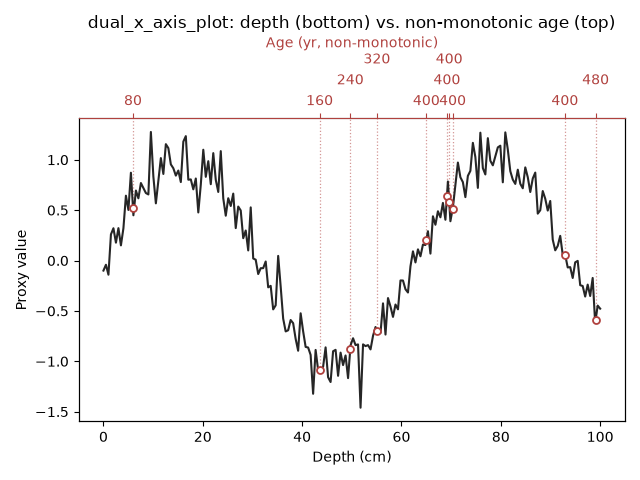

10 secondary ticks placed


In [15]:
rng = np.random.default_rng(0)
depth = np.linspace(0, 100, 200)
age = 5 * depth + 80 * np.sin(depth / 8) + rng.normal(0, 2, depth.shape)
proxy = np.sin(depth / 10) + 0.15 * rng.normal(size=depth.shape)

ax, ax2, crossings = dual_x_axis_plot(
    depth, age, proxy,
    x1_label="Depth (cm)",
    x2_label="Age (yr, non-monotonic)",
    n_ticks=8,
)
ax.set_ylabel("Proxy value")
ax.set_title("dual_x_axis_plot: depth (bottom) vs. non-monotonic age (top)")
plt.tight_layout()
plt.show()
print(f"{len(crossings)} secondary ticks placed")

### 2b — `add_step_secondary_axis`: step number, automatically

`add_step_secondary_axis(ax, x1, y)` inspects `x1` and picks one of two strategies:

* **Single monotonic pass** (e.g. a plain sorted scan) — `x1 -> step` is invertible,
  so this hands the interpolated forward/inverse mapping straight to matplotlib's own
  `Axes.secondary_xaxis`. You get a real, densely and automatically ticked axis that
  reflects `x1`'s true shape (linear, log-spaced, whatever it is) — no more manually
  hunting for a handful of crossing points.
* **Repeated / "sawtooth"** (`x1` revisits the same range, e.g. because you
  deliberately repeat a scan several times to average out slow drift) — `x1` is split
  into its maximal monotonic runs ("segments") at each point it changes direction. A
  tick *stride* is derived once from one segment's length (snapped to a divisor of
  that length) so ticks from different repeats land on the *same* phase and get
  stacked on top of each other, rather than drifting to nearby-but-different
  positions.

Either way, every point where `x1` changes direction (a "turning point" — e.g. a
sawtooth's reset) is labelled directly on the curve with its step index
(`label_turning_points=True`, the default), decluttered with `adjustText` so labels
don't overlap even when several turning points cluster together.

In [16]:
# Shared plotting boilerplate for the examples below.
def plot_step_axis_demo(x1, y, title, **kwargs):
    fig, ax = plt.subplots(figsize=(8, 3.2))
    ax.plot(x1, y, ".-", color="0.25", markersize=4, linewidth=1)
    ax.set_xlabel("x1 (scan parameter)")
    ax.set_ylabel("y")
    ax2, crossings, turning_points = add_step_secondary_axis(ax, x1, y, **kwargs)
    ax.set_title(title)
    plt.tight_layout()
    plt.show()
    return ax, ax2, crossings, turning_points

#### 2b.1 — baseline: monotonic `x1`, single pass

Ten log-spaced values, visited once. `x1` is invertible, so this is a real
`secondary_xaxis`: matplotlib fills in as many "nice" ticks as fit, all of them
nonlinearly spaced to match `x1`'s log spacing. No turning points — the curve never
changes direction.

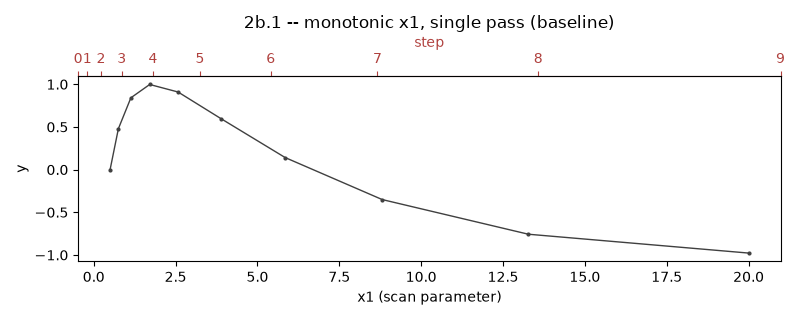

turning points: []


In [17]:
x1_base = np.geomspace(0.5, 20, 10)

ax, ax2, crossings, tps = plot_step_axis_demo(
    x1_base, np.sin(np.arange(10) / 2),
    title="2b.1 -- monotonic x1, single pass (baseline)",
)
print("turning points:", tps)

#### 2b.2 — sawtooth: 2 exact repeats

The same 10 log-spaced values, visited twice in a row (`x1` resets to its start
half-way through). The automatically-derived stride (2, a divisor of the 10-point
cycle) makes steps 0 & 10, 2 & 12, 4 & 14, … land at identical `x1` positions and get
stacked; the reset itself (steps 9 and 10) is called out with turning-point labels
right on the curve.

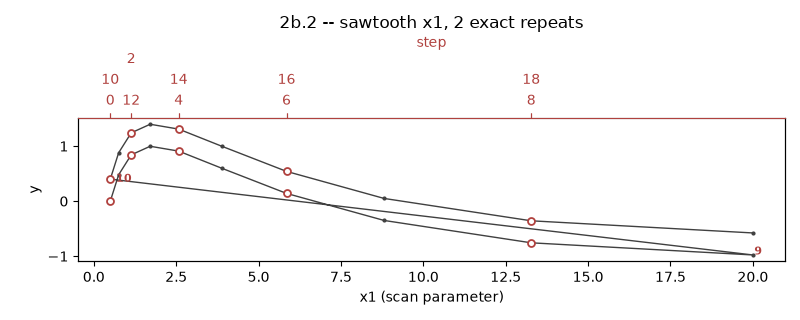

turning points: [9, 10]


In [18]:
n_rep = 2
step = np.arange(n_rep * len(x1_base))
x1_2rep = np.tile(x1_base, n_rep)
# slow linear drift between repeats, so the two passes are visually distinguishable
y_2rep = np.sin((step % len(x1_base)) / 2) + 0.4 * (step // len(x1_base))

ax, ax2, crossings, tps = plot_step_axis_demo(
    x1_2rep, y_2rep, title="2b.2 -- sawtooth x1, 2 exact repeats",
)
print("turning points:", tps)

#### 2b.3 — sawtooth: 3 exact repeats

Three repeats now stack *three* step ticks at each aligned `x1` position — exactly as
many collisions as the stagger logic's `n_levels=3` was written to handle. A 4th
repeat would start reusing stagger levels and ticks would begin to overlap again — a
first concrete thing to tweak. Four turning points now (two per internal reset).

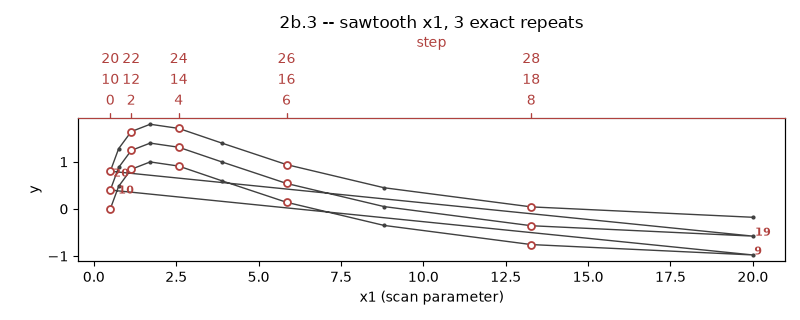

turning points: [9, 10, 19, 20]


In [19]:
n_rep = 3
step = np.arange(n_rep * len(x1_base))
x1_3rep = np.tile(x1_base, n_rep)
y_3rep = np.sin((step % len(x1_base)) / 2) + 0.4 * (step // len(x1_base))

ax, ax2, crossings, tps = plot_step_axis_demo(
    x1_3rep, y_3rep, title="2b.3 -- sawtooth x1, 3 exact repeats",
)
print("turning points:", tps)

#### 2b.4 — sawtooth with per-repeat jitter (near-, not exact, collisions)

Real repeated scans rarely land on *exactly* the same `x1` values each time (motor
backlash, slightly different set-points, …). Here each repeat's `x1` values are
perturbed by a few percent, so colliding ticks are close together but not identical.

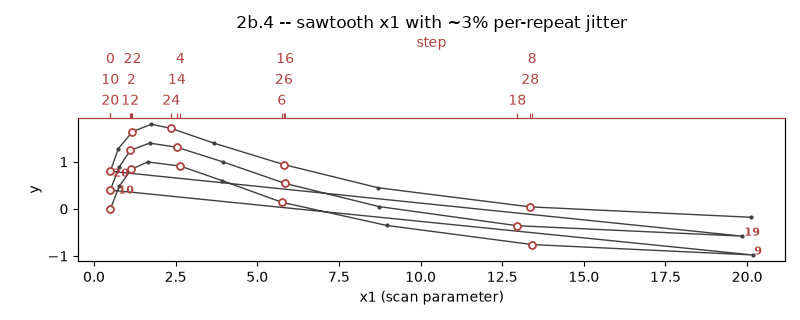

turning points: [9, 10, 19, 20]


In [20]:
rng = np.random.default_rng(1)
n_rep = 3
x1_jitter = np.concatenate([
    x1_base * (1 + rng.normal(0, 0.03, size=x1_base.shape)) for _ in range(n_rep)
])
step = np.arange(len(x1_jitter))
y_jitter = np.sin((step % len(x1_base)) / 2) + 0.4 * (step // len(x1_base))

ax, ax2, crossings, tps = plot_step_axis_demo(
    x1_jitter, y_jitter, title="2b.4 -- sawtooth x1 with ~3% per-repeat jitter",
)
print("turning points:", tps)

#### 2b.5 — uneven repeats (scan aborted during the last cycle)

Two full repeats plus a partial third one — e.g. the scan was stopped early. The
colliding cluster at the start of each cycle still lines up; the partial cycle simply
contributes fewer ticks near the end.

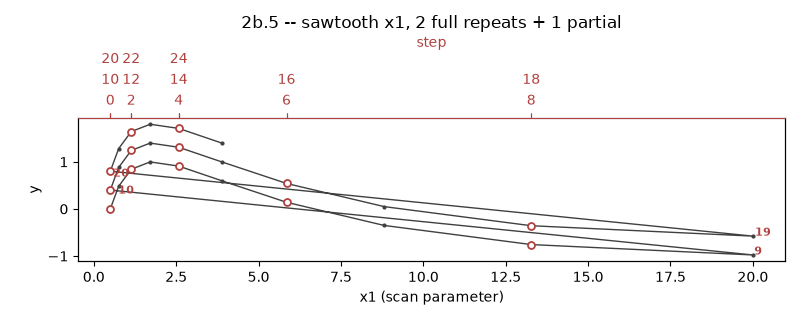

turning points: [9, 10, 19, 20]


In [21]:
x1_uneven = np.concatenate([x1_base, x1_base, x1_base[:6]])
step = np.arange(len(x1_uneven))
cycle = step // len(x1_base)
y_uneven = np.sin((step % len(x1_base)) / 2) + 0.4 * cycle

ax, ax2, crossings, tps = plot_step_axis_demo(
    x1_uneven, y_uneven, title="2b.5 -- sawtooth x1, 2 full repeats + 1 partial",
)
print("turning points:", tps)

#### 2b.6 — fully reordered scan (every point is a turning point)

The degenerate end of the spectrum: a scan parameter visited in a scrambled order that
isn't a clean sawtooth at all (e.g. a randomised scan order, or a timetool-corrected
delay). Segment detection falls back gracefully — almost every point is its own
1-2-sample segment, so almost every point gets both a secondary tick *and* a
turning-point label. This is the same non-monotonic order used in earlier iterations
of this notebook, now handled automatically instead of via hand-picked `tick_values`.

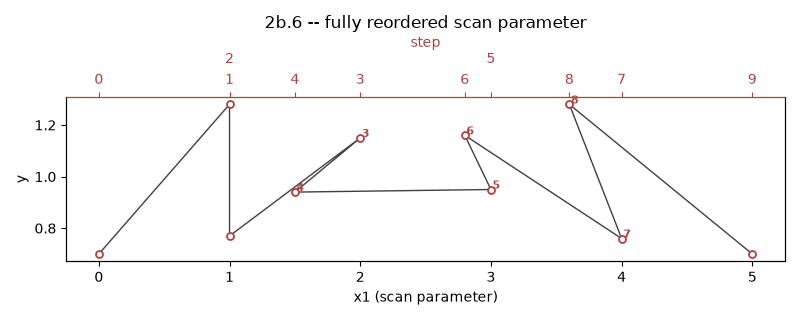

turning points: [3, 4, 5, 6, 7, 8]


In [22]:
x1_scrambled = np.array([0.0, 1.0, 1.0, 2.0, 1.5, 3.0, 2.8, 4.0, 3.6, 5.0])
y_scrambled = np.array([0.70, 1.28, 0.77, 1.15, 0.94, 0.95, 1.16, 0.76, 1.28, 0.70])

ax, ax2, crossings, tps = plot_step_axis_demo(
    x1_scrambled, y_scrambled, title="2b.6 -- fully reordered scan parameter",
)
print("turning points:", tps)

### 2c — built into `Scan.plot` and the `Array` repr

`Scan.plot(..., add_step_axis=True)` adds this same automatic step-number axis — no
need to call `add_step_secondary_axis` yourself. It's also what `escape.Array`'s
default notebook repr now uses for a scalar array with more than one scan step, so a
repeated or non-monotonic scan order (and its turning points) is always visible at a
glance. Here we build a scan whose parameter sweeps the same range twice (example
2b.2's data, but constructed with `make_scan` and plotted through the real API).

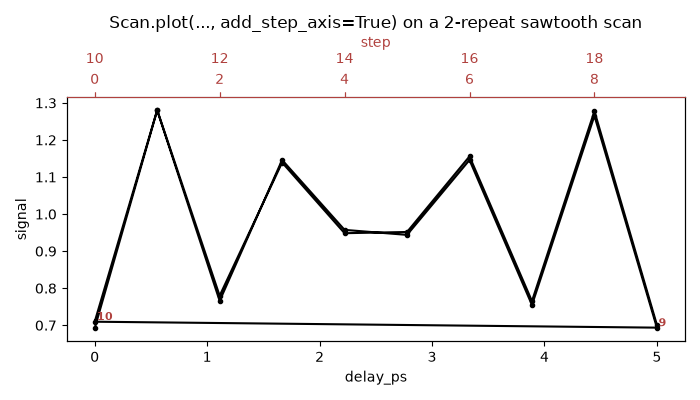

In [23]:
sig = make_scan(
    n_steps=20,
    n_events_per_step=300,
    scan_par_name="delay_ps",
    scan_par_values=np.tile(np.linspace(0.0, 5.0, 10), 2),  # two repeats of the same sweep
    name="signal",
    seed=0,
)

fig, ax = plt.subplots(figsize=(7, 4))
sig.scan.plot(axis=ax, fmt="k.-", add_step_axis=True)
ax.set_title("Scan.plot(..., add_step_axis=True) on a 2-repeat sawtooth scan")
plt.tight_layout()
plt.show()


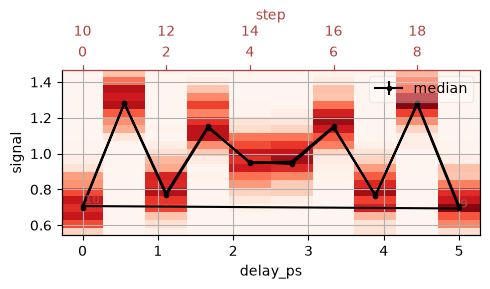

In [24]:
sig  # default repr: histogram-of-steps + median, with the step-number axis on top

### 2d — toggling the step axis interactively

`escape.storage.storage.SHOW_STEP_AXIS_IN_REPR` is a *global* on/off switch for the
step axis across every repr plot. For a one-off look without it — without changing
that global — `arr.interactive()` adds a **"show steps"** checkbox below the figure
whenever there's a step axis to toggle at all (a multi-step scan that isn't a pure 2-D
grid heatmap, which has no notion of scan steps on its axes). Toggling it rebuilds
just that plot.

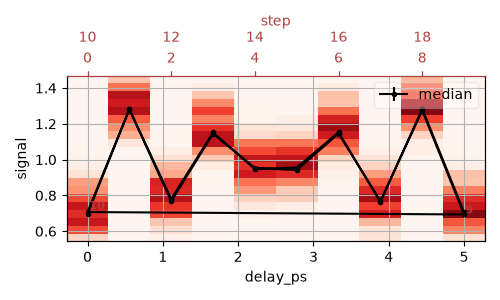

In [25]:
sig.interactive()